<a href="https://colab.research.google.com/github/sara-sgit/Plant-Disease-Classification/blob/main/Feature_Selection_1_ACP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle as pk
import os

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score


# Import features

In [ ]:
with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/DenseNet/Leaky relu/ train_densenet_80_leakyrelu.pickle', 'rb') as f:
     x_tr1= pk.load(f)


with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/Resnet/Leaky relu/ F_train_RESNET_Leakyrelu.pickle', 'rb') as f:
     x_tr2= pk.load(f)

with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/vgg/LEAKY RELU/ right_features_training_LEAKYREL.pickle', 'rb') as f:
     x_tr3= pk.load(f)



with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/DenseNet/Sigmoid/F_TEST_DeneseNet_sigmo.pickle', 'rb') as f:
     x_ts11= pk.load(f)


with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/Resnet/sigmoid/ F_TEST_RESNET_sigmoid.pickle', 'rb') as f:
     x_ts22= pk.load(f)

with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/vgg/SIGMOID/F_test_VGG_SiGmoiD.pickle', 'rb') as f:
     x_ts33= pk.load(f)

#_______________________________________________________________________________________________________________


Fusion

In [ ]:

# Concatenate feature sets along columns (axis=1) to create the final training and testing feature matrices
x_tr= np.concatenate((x_tr1 ,x_tr2,x_tr3),axis=1)
x_ts= np.concatenate((x_ts1 ,x_ts2,x_ts3),axis=1)

In [ ]:

# Standardize the training and testing feature matrices:
# This scales the data to have zero mean and unit variance (important for PCA and many ML algorithms)
scR= StandardScaler()
X_trainR = scR.fit_transform(x_tr) # Fit to training data and transform it
X_testR = scR.transform(x_ts)# Transform testing data using the same scaling

# Apply PCA (Principal Component Analysis) to reduce dimensionality:
from sklearn.decomposition import PCA
number_of_features= 100  # Set the number of principal components to keep
pcaR = PCA(number_of_features)
# Fit PCA on the standardized training data and transform it to the reduced feature space
X_train_pR = pcaR.fit_transform(X_trainR)
# Transform the standardized testing data using the same PCA (no refitting)
X_test_pR = pcaR.transform(X_testR)


**SVM AFTER PCA**::  ⛅

In [ ]:
# Create an SVM pipeline with standard scaling and RBF kernel

svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale'))


# Fit the SVM model to the training data (converted to float32 for GPU compatibility)
svm.fit(X_train_pR.astype(np.float32), y_tr.astype(np.float32))
# Predict the labels of the test data
y_pred = svm.predict(X_test_pR .astype(np.float32))

#________________________________  _ ######### Confusion Matrix & Classification Report #########  #############_____________________________________________________________

from sklearn.metrics import classification_report, confusion_matrix

# Display the confusion matrix to evaluate classification performance
print('confusion matrix')
# (Optional) Calculate simple accuracy manually

print(confusion_matrix(y_ts,y_pred))
labels=y_ts
sum((labels==y_pred)*1)/len(y_pred)


confusion matrix
[[424   0   1   0   0   0   0   0   0   0]
 [  3 172  12   0   4   4   4   0   1   0]
 [  0   3 376   0   0   0   3   0   0   0]
 [  0   1   1 184   2   2   0   0   0   0]
 [  1   0   2   1 350   0   0   0   0   0]
 [  0   0   0   0   0 329   4   0   0   0]
 [  0   2   1   0   0  10 268   0   0   0]
 [  0   0   0   0   0   0   0 642   0   0]
 [  0   0   0   1   1   0   0   0  73   0]
 [  0   0   0   0   0   0   4   0   0 314]]


np.float64(0.97875)

Save model for the deployments

In [ ]:

# Save the fitted StandardScaler object to a file for later use (e.g., when deploying the model)


from joblib import dump, load
dump(scR, '/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/Standar.joblib')

['/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/Standar.joblib']

In [ ]:
from joblib import dump, load
dump(pcaR, '/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/pca.joblib')

['/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/pca.joblib']

In [ ]:
from joblib import dump, load
dump(svm, '/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/svm.joblib')

['/content/drive/MyDrive/BENNANI_AKRIB/Models of acp , standarscaller , svm/svm.joblib']

In [ ]:
#In case we want to calculate gamma that was used when we set it as scale
sc = StandardScaler()
X_train = sc.fit_transform(x_tr)

gamma_of_normlized_data = 1 / (4096 * X_train.var())
print(gamma_of_normlized_data)

0.0002441409742464651


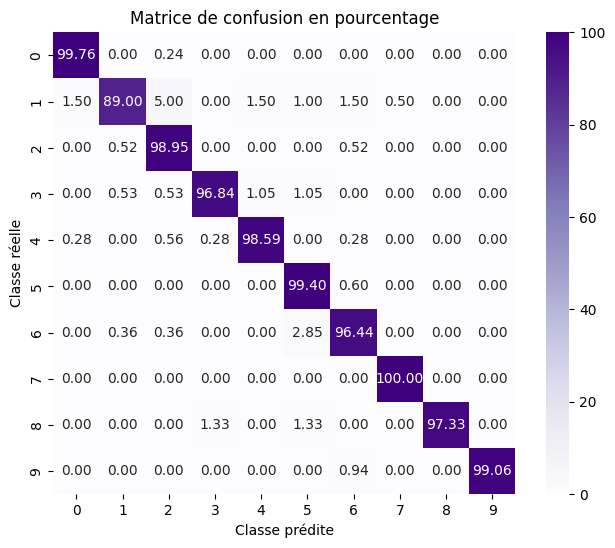

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_ts, y_pred)

# Convert the confusion matrix to percentages (row-wise normalization)
conf_matrix_percentage = conf_matrix / np.sum(conf_matrix, axis=1, keepdims=True) * 100

# Create class labels (as strings) from the unique classes in the true labels
labels = np.unique(y_ts)
labels = [str(label) for label in labels]

# Plot the confusion matrix as a heatmap with percentages (no '%' symbol shown)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Purples', cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (Percentage)')
plt.show()


# Saving models for app deployment: StandardScaler, SVM, and PCA (ACP)


In [ ]:
from joblib import dump, load
dump(scR, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/standerscalerResnet100.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/standerscalerResnet100.joblib']

In [ ]:
from joblib import dump, load
dump(scV, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/standerscalerVGG100.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/standerscalerVGG100.joblib']

In [ ]:
from joblib import dump, load
dump(pcaD, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781DenseNet100.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781DenseNet100.joblib']

In [ ]:
from joblib import dump, load
dump(pcaR, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781Resnet100.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781Resnet100.joblib']

In [ ]:
from joblib import dump, load
dump(pcaV, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781GG100.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/acp9781GG100.joblib']

In [ ]:
from joblib import dump, load
dump(svmf, '/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/svm_for_models_fusioned_after acp98.28_300total.joblib')

['/content/drive/MyDrive/Models_interface/approche1/model_acp_final/sigmo/svm_for_models_fusioned_after acp98.28_300total.joblib']

In [ ]:

# Predict the labels of the test data
y_pred = svm.predict(x_ts.astype(np.float32))

#________________________________   #########   #matrice de confusion    #############_____________________________________________________________

from sklearn.metrics import classification_report, confusion_matrix

print('confusion matrix')
print(confusion_matrix(y_ts,y_pred))
labels=y_ts
sum((labels==y_pred)*1)/len(y_pred)

confusion matrix
[[424   0   1   0   0   0   0   0   0   0]
 [  2 179   9   0   4   4   2   0   0   0]
 [  0   3 375   1   1   0   2   0   0   0]
 [  0   1   3 182   2   2   0   0   0   0]
 [  2   0   3   1 347   1   0   0   0   0]
 [  0   0   0   0   0 329   4   0   0   0]
 [  0   1   2   0   1  10 263   0   0   4]
 [  0   0   0   0   0   0   0 642   0   0]
 [  0   0   0   1   0   0   0   0  74   0]
 [  0   0   0   0   0   0   2   0   0 316]]


0.9784375